# **Capacitación en Secuenciación por NGS  y análisis bioinformático de *Salmonella* spp. para la vigilancia en salud pública**

## **Procesamiento de resultados TerraBio**

Este instructivo tiene como objetivo procesar los resultados obtenidos a partir de la herramienta **TerraBio**, de manera que todos los datos se consoliden en un único archivo de salida en formato Excel.

### **1. Objetivo**
Describir el procedimiento para generar el informe de control de calidad y resultados del análisis por WGS de bacterias de importancia en salud pública.


### **2. Alcance**
Aplica a los resultados generados por el laboratorio de genómica durante el análisis por WGS de bacterias de importancia en salud pública.


### **3. Definiciones y abreviaturas**
WGS: Secuenciación de genoma completo (del inglés Whole genome sequencing).

### **4 Procedimiento**

### **4.1 Generación del archivo Excel de resultados QC, ID, virulencia y resistencia**


### **Carga de archivos al entorno de ejecución**

1. En el panel lateral izquierdo, haga clic en el ícono de la carpeta.

2. Haga clic en los tres puntos a la derecha de la carpeta y seleccione la opción *Subir*.

3. Seleccione los siguientes archivos:

- **Salida_Terra_Todo.xlsx:** archivo de salida generado por la herramienta TerraBio.

- **CNRB_WGS_Demograficos.xlsx:** archivo con los datos demográficos de las bacterias secuenciadas.

**Importante**: Los archivos cargados se almacenan de forma temporal y estarán disponibles únicamente durante la sesión activa del cuaderno.


### **4.2 Script para descargar y activar las librerias necesarias**
Ejecute el siguiente código para instalar y cargar las librerías de R requeridas para el procesamiento de los datos.

In [ ]:
#Instalar librerias
install.packages("readxl")
install.packages("writexl")
install.packages("rio")
install.packages("dplyr")
install.packages("openxlsx")
install.packages("ggplot2")
install.packages("ggpubr")
install.packages("gridExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘r

In [ ]:
#Definir directorio de trabajo
setwd("/home/jovyan/work/Tutorial_Panama/Notebooks_procesamiento")

In [9]:
#Cargar librerias
library(readxl)  #libreria para leer Excel
library(writexl)  #libreria para modificar Excel
library(rio)
library(dplyr)
library(openxlsx)
library(ggplot2)
library(ggpubr)
library(gridExtra)

ERROR: Error in library(openxlsx): there is no package called ‘openxlsx’


### **4.3 Importación y visualización de los datos de origen**

Para poder trabajar los archivos de entrada en el ambiente R debe crear los objetos específicos utilizando el siguiente código:

In [ ]:
#Importación de datos (crear objetos en R a partir de la fuente de datos)
datos <- import("Salida_Terra_Todo.xlsx")
demograficos <- import("CNRB_WGS_Demograficos.xlsx")

Luego de la ejecución deberá observar dos objetos nuevos "datos" y "demograficos" en la pantalla superior derecha "Global Environment".

### **4.4 Transformar los tipos de datos para que se puedan trabajar en R**

Para facilitar la manipulación de los datos en el ambiente R debe transformar la naturaleza de los datos en los objetos creados, para esto ejecute el código que se detalla a contuinuación.

In [ ]:
#cambiar tipos de datos

datos <-datos %>% mutate(combined_mean_q_clean = as.numeric(combined_mean_q_clean))
datos <-datos %>% mutate(combined_mean_q_raw = as.numeric(combined_mean_q_raw))
datos <-datos %>% mutate(combined_mean_readlength_clean = as.numeric(combined_mean_readlength_clean))
datos <-datos %>% mutate(combined_mean_readlength_raw = as.numeric(combined_mean_readlength_raw))
datos <-datos %>% mutate(est_coverage_clean = as.numeric(est_coverage_clean))
datos <-datos %>% mutate(est_coverage_raw = as.numeric(est_coverage_raw))
datos <-datos %>% mutate(kmerfinder_template_coverage = as.numeric(kmerfinder_template_coverage))
datos <-datos %>% mutate(midas_secondary_genus_abundance = as.numeric(midas_secondary_genus_abundance))
datos <-datos %>% mutate(midas_secondary_genus_coverage = as.numeric(midas_secondary_genus_coverage))
datos <-datos %>% mutate(quast_gc_percent = as.numeric(quast_gc_percent))
datos <-datos %>% mutate(r1_mean_q_clean = as.numeric(r1_mean_q_clean))
datos <-datos %>% mutate(r1_mean_q_raw = as.numeric(r1_mean_q_raw))
datos <-datos %>% mutate(r1_mean_readlength_clean = as.numeric(r1_mean_readlength_clean))
datos <-datos %>% mutate(r1_mean_readlength_raw = as.numeric(r1_mean_readlength_raw))
datos <-datos %>% mutate(r2_mean_q_clean = as.numeric(r2_mean_q_clean))
datos <-datos %>% mutate(r2_mean_q_raw = as.numeric(r2_mean_q_raw))
datos <-datos %>% mutate(r2_mean_readlength_clean = as.numeric(r2_mean_readlength_clean))
datos <-datos %>% mutate(r2_mean_readlength_raw = as.numeric(r2_mean_readlength_raw))

demograficos <- demograficos |>
  mutate_if(is.character, as.factor)

demograficos <- demograficos |>
  mutate_if(is.logical, as.factor)

datos <- datos |>
  mutate_if(is.character, as.factor)

datos <- datos |>
  mutate_if(is.logical, as.factor)

### **4.5 Control de calidad de la corrida de secuenciación y de las secuencias y ensamblajes individuales**

El siguiente código permite crear los objetos necesarios para crear archivos intermedios para que puedan ser unidos en un solo dataframe (tabla de resultados)

**En la línea donde se crea el objeto "columnas a copiar 2" asegúrese de actualizar la variable entity con el nombre real de la columna en el archivo Salida_Terra_Todo**

In [ ]:
#Para combinar datos de dos objetos iniciales y tener un tercer objeto combinado

columnas_a_copiar <- demograficos[, c("Key", "Microorganismo")]
#Agregar columnas
#Crear columnas
columnas_a_copiar$Genome_size_Mb <- NA
columnas_a_copiar$GC_content <- NA
columnas_a_copiarB <- demograficos[, c("Key", "Analisis solicitado" )]
columnas_a_copiar <- merge(columnas_a_copiar, columnas_a_copiarB, by = "Key", all.x = TRUE)

columnas_a_copiar2 <- datos[, c("entity:CRIN-M07450-20260306_sample_id", "assembly_length", "combined_mean_q_clean", "combined_mean_readlength_clean", "est_coverage_clean", "n50_value", "number_contigs", "quast_gc_percent", "quast_version", "busco_database", "busco_results", "busco_version", "midas_primary_genus", "midas_secondary_genus", "read_screen_clean", "read_screen_raw","tbp_parser_average_genome_depth", "tbp_parser_genome_percent_coverage", "tbp_parser_version", "tbprofiler_median_depth", "tbprofiler_version", "seq_platform", "trimmomatic_version")]



#Cambiar nombre de columnas
colnames(columnas_a_copiar2)[1]<-"Key"


#Para unir los dos archivos

QCresult <- merge(columnas_a_copiar, columnas_a_copiar2, by = "Key", all.x = TRUE)

A continuación se detallan los comandos para visualización de los principales parámetros de calidad a evaluar para las secuencias generadas utilizando boxplots.

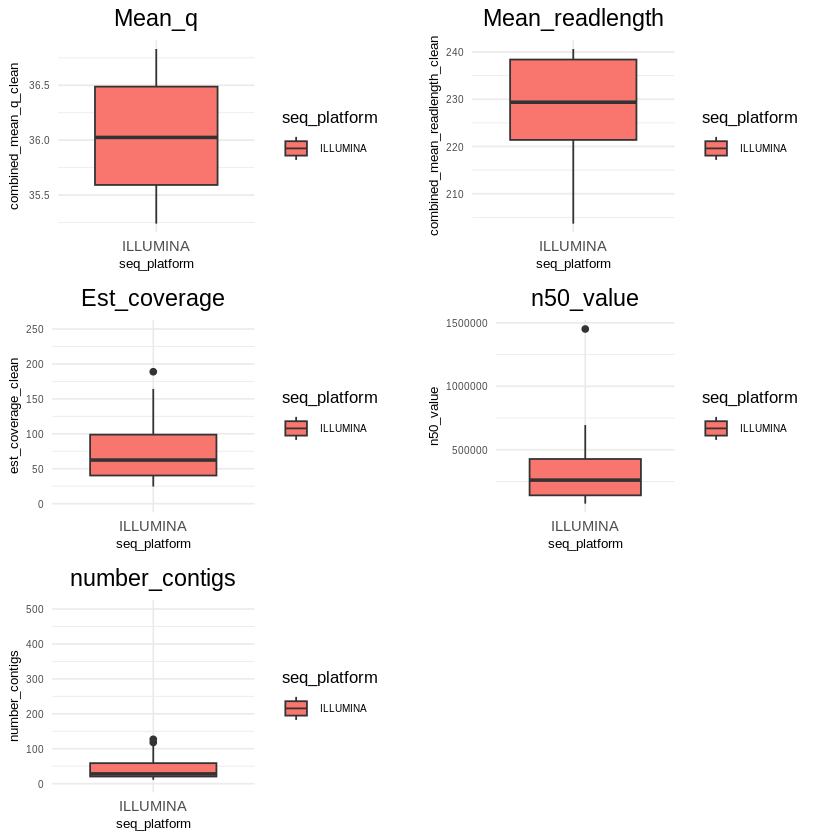

In [ ]:
#Graficos QC

# Gráfico de caja

g1 <- ggplot (QCresult, aes(x = seq_platform, y = combined_mean_q_clean, fill = seq_platform)) +
  geom_boxplot() +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 6)) +
  theme(axis.title = element_text(size = 8)) +
  theme(legend.text = element_text(size = 6)) +
  theme(legend.title = element_text(size = 10)) +
  labs(title = "Mean_q") +
  theme(plot.title = element_text(size = 14)) +
  theme(plot.title = element_text(hjust = 0.5))

g2 <- QCresult %>%
  ggplot(aes(x = seq_platform, y = combined_mean_readlength_clean, fill = seq_platform)) +
  geom_boxplot() +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 6)) +
  theme(axis.title = element_text(size = 8)) +
  theme(legend.text = element_text(size = 6)) +
  theme(legend.title = element_text(size = 10)) +
  labs(title = "Mean_readlength") +
  theme(plot.title = element_text(size = 14)) +
  theme(plot.title = element_text(hjust = 0.5))

g3 <- QCresult %>%
  ggplot(aes(x = seq_platform, y = est_coverage_clean, fill = seq_platform)) +
  geom_boxplot() +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 6)) +
  theme(axis.title = element_text(size = 8)) +
  theme(legend.text = element_text(size = 6)) +
  theme(legend.title = element_text(size = 10)) +
  labs(title = "Est_coverage") +
  scale_y_continuous(limits = c(0, 250)) +
  theme(plot.title = element_text(size = 14)) +
  theme(plot.title = element_text(hjust = 0.5))

g4 <- QCresult %>%
  ggplot(aes(x = seq_platform, y = n50_value, fill = seq_platform)) +
  geom_boxplot() +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 6)) +
  theme(axis.title = element_text(size = 8)) +
  theme(legend.text = element_text(size = 6)) +
  theme(legend.title = element_text(size = 10)) +
  labs(title = "n50_value") +
  theme(plot.title = element_text(size = 14)) +
  theme(plot.title = element_text(hjust = 0.5))

g5 <- QCresult %>%
  ggplot(aes(x = seq_platform, y = number_contigs, fill = seq_platform)) +
  geom_boxplot() +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 6)) +
  theme(axis.title = element_text(size = 8)) +
  theme(legend.text = element_text(size = 6)) +
  theme(legend.title = element_text(size = 10)) +
  labs(title = "number_contigs") +
  scale_y_continuous(limits = c(0, 500)) +
  theme(plot.title = element_text(size = 14)) +
  theme(plot.title = element_text(hjust = 0.5))


grid.arrange(g1, g2, g3, g4, g5, ncol = 2)

Revise que los parámetros de calidad mostrados sean los adecuados para proseguir con la generación de resultados.

### **4.6 Generación del informe combinado de tablas en formato .xlsx**

#### **4.6.1 Script para generar las tablas de datos independientes de identificación, virulencia y RAM**

Después de generar y evaluar los archivos y gráficos de calidad proceda a generar las tablas de datos independientes de identificación, virulencia y RAM:

**En las líneas donde se crea los objetos "columnas a copiar 2" asegúrese de actualizar la variable entity con el nombre real de la columna en el archivo Salida_Terra_Todo (Identificación de la corrida)**

In [ ]:
# Resistencia

columnas_a_copiarR1 <- demograficos[, c("Key", "Microorganismo", "Analisis solicitado")]

columnas_a_copiarR2 <- datos[, c("entity:CRIN-M07450-20260306_sample_id",	"amrfinderplus_amr_betalactam_betalactam_genes",	"amrfinderplus_amr_betalactam_carbapenem_genes",	"amrfinderplus_amr_betalactam_cephalosporin_genes",	"amrfinderplus_amr_betalactam_cephalothin_genes",	"amrfinderplus_amr_betalactam_genes",	"amrfinderplus_amr_betalactam_methicillin_genes",	"amrfinderplus_amr_classes",	"amrfinderplus_amr_core_genes",	"amrfinderplus_amr_plus_genes",	"amrfinderplus_amr_subclasses",	"amrfinderplus_db_version",	"kleborate_genomic_resistance_mutations",	"kleborate_key_resistance_genes",	"kleborate_resistance_score",	"kleborate_version",	"resfinder_db_version",	"resfinder_predicted_pheno_resistance",	"resfinder_predicted_resistance_Amp",	"resfinder_predicted_resistance_Axo",	"resfinder_predicted_resistance_Azm",	"resfinder_predicted_resistance_Cip",	"resfinder_predicted_resistance_Smx",	"resfinder_predicted_resistance_Tmp",	"resfinder_predicted_xdr_shigella",	"staphopiasccmec_types_and_mecA_presence",	"staphopiasccmec_version",	"tbprofiler_resistance_genes",	"tbprofiler_version",	"theiaprok_illumina_pe_version")]

#Cambiar nombre de columnas
colnames(columnas_a_copiarR2)[1]<-"Key"


#Para unir los dos archivos

Rresult <- merge(columnas_a_copiarR1, columnas_a_copiarR2, by = "Key", all.x = TRUE)


# Virulencia

columnas_a_copiarV2 <- datos[, c("entity:CRIN-M07450-20260306_sample_id",	"abricate_abaum_database",	"abricate_abaum_plasmid_type_genes",	"abricate_abaum_version",	"abricate_database",	"abricate_genes",	"abricate_version",	"abricate_vibrio_ctxA",	"abricate_vibrio_database",	"abricate_vibrio_ompW",	"abricate_vibrio_toxR",	"abricate_vibrio_version",	"amrfinderplus_stress_genes",	"amrfinderplus_version",	"amrfinderplus_virulence_genes",		"kleborate_version",	"plasmidfinder_db_version",	"plasmidfinder_plasmids",	"shigeifinder_num_virulence_plasmid_genes",	"shigeifinder_version", "stxtyper_all_hits", "stxtyper_complete_operons", "stxtyper_novel_hits", "stxtyper_num_hits", "stxtyper_partial_hits", "stxtyper_version",	"theiaprok_illumina_pe_version")]

#Cambiar nombre de columnas
colnames(columnas_a_copiarV2)[1]<-"Key"


#Para unir los dos archivos

Vresult <- merge(columnas_a_copiarR1, columnas_a_copiarV2, by = "Key", all.x = TRUE)


# ID

columnas_a_copiarID2 <- datos[, c("entity:CRIN-M07450-20260306_sample_id",	"ani_highest_percent",	"ani_mummer_version",	"ani_top_species_match",	"gambit_db_version",	"gambit_predicted_taxon",	"gambit_predicted_taxon_rank",	"gambit_version",	"abricate_version",	"kmerfinder_database",	"kmerfinder_query_coverage",	"kmerfinder_template_coverage",	"kmerfinder_top_hit",	"ts_mlst_allelic_profile",	"ts_mlst_predicted_st",	"ts_mlst_pubmlst_scheme",	"ts_mlst_version",	"serotypefinder_serotype",	"ectyper_predicted_serotype",	"ectyper_version",	"shigatyper_ipaB_presence_absence",	"shigatyper_notes",	"shigatyper_predicted_serotype",	"shigatyper_version",	"shigeifinder_H_antigen",	"shigeifinder_O_antigen",	"shigeifinder_cluster",	"shigeifinder_ipaH_presence_absence",	"shigeifinder_ipaH_presence_absence_reads",	"shigeifinder_notes",	"shigeifinder_serotype",	"shigeifinder_version",	"sonneityping_final_genotype",	"sonneityping_genotype_confidence",	"sonneityping_genotype_name",	"sonneityping_mykrobe_version",	"sonneityping_species",	"sistr_predicted_serotype",	"sistr_version",	"seqsero2s_predicted_antigenic_profile",	"seqsero2s_predicted_contamination",	"seqsero2s_predicted_serotype",	"seqsero2s_version",	"genotyphi_final_genotype",	"genotyphi_genotype_confidence",	"genotyphi_species",	"genotyphi_version",	"lissero_serotype",	"lissero_version",	"abricate_vibrio_biotype",	"abricate_vibrio_database",	"abricate_vibrio_serogroup",	"abricate_vibrio_version",	"srst2_vibrio_biotype",	"srst2_vibrio_ctxA",	"srst2_vibrio_database",	"srst2_vibrio_ompW",	"srst2_vibrio_serogroup",	"srst2_vibrio_toxR",	"srst2_vibrio_version",	"kleborate_klocus",	"kleborate_klocus_confidence",	"kleborate_ktype",	"kleborate_mlst_sequence_type",	"kleborate_olocus",	"kleborate_olocus_confidence",	"kleborate_otype",	"kleborate_version",	"meningotype_BAST",	"meningotype_FetA",	"meningotype_NHBA",	"meningotype_NadA",	"meningotype_PorA",	"meningotype_PorB",	"meningotype_fHbp",	"meningotype_serogroup",	"meningotype_version",	"ngmaster_ngmast_porB_allele",	"ngmaster_ngmast_sequence_type",	"ngmaster_ngmast_tbpB_allele",	"ngmaster_ngstar_23S_allele",	"ngmaster_ngstar_gyrA_allele",	"ngmaster_ngstar_mtrR_allele",	"ngmaster_ngstar_parC_allele",	"ngmaster_ngstar_penA_allele",	"ngmaster_ngstar_ponA_allele",	"ngmaster_ngstar_porB_allele",	"ngmaster_ngstar_sequence_type",	"ngmaster_version",	"pasty_serogroup",	"pasty_serogroup_coverage",	"pasty_serogroup_fragments",	"pasty_version",	"poppunk_GPS_db_version",	"poppunk_gps_cluster",	"poppunk_version",	"seroba_ariba_identity",	"seroba_ariba_serotype",	"seroba_details",	"seroba_serotype",	"seroba_version",	"pbptyper_predicted_1A_2B_2X",	"pbptyper_version",	"emmtyper_emm_type",	"emmtyper_version",	"emmtypingtool_emm_type",	"emmtypingtool_version",	"hicap_genes",	"hicap_serotype",	"hicap_version",	"agrvate_agr_group",	"agrvate_agr_match_score",	"agrvate_agr_multiple",	"agrvate_summary",	"agrvate_version",	"staphopiasccmec_types_and_mecA_presence",	"staphopiasccmec_version",	"spatyper_type",	"spatyper_version",	"kaptive_k_locus",	"kaptive_k_type",	"kaptive_kl_confidence",	"kaptive_oc_locus",	"kaptive_ocl_confidence",	"kaptive_version",	"legsta_predicted_sbt",	"legsta_version",	"tbprofiler_dr_type",	"tbprofiler_main_lineage",	"tbprofiler_median_depth",	"tbprofiler_sub_lineage",	"tbprofiler_version",	"theiaprok_illumina_pe_version"
)]

#Cambiar nombre de columnas
colnames(columnas_a_copiarID2)[1]<-"Key"


#Para unir los dos archivos

IDresult <- merge(columnas_a_copiarR1, columnas_a_copiarID2, by = "Key", all.x = TRUE)

### **4.7 Script para generar el informe combinado de tablas en formato .xlsx**

Por último, a partir de los archivos individuales que creó en el paso anterior proceda a crear un archivo final combinado que reúna los archivos de demográficos con los resultados obtenidos para control de calidad, identificación, resistencia y virulencia.

In [ ]:
#Para crear un archivo Excel para reporte de resultados
#Crear un nuevo workbook
Resultados <- createWorkbook()

#Crear las hojas del workbook
addWorksheet(Resultados, "demograficos")
addWorksheet(Resultados, "QC")
addWorksheet(Resultados, "ID_Tipificacion")
addWorksheet(Resultados, "Resistencia")
addWorksheet(Resultados, "Virulencia")

#escribir dataframe (resultados respectivos) en hojas correspondientes

writeData(Resultados, sheet = "demograficos", demograficos)
writeData(Resultados, sheet = "QC", QCresult)
writeData(Resultados, sheet = "ID_Tipificacion", IDresult)
writeData(Resultados, sheet = "Resistencia", Rresult)
writeData(Resultados, sheet = "Virulencia", Vresult)

#Guardar workbook en archivo Excell
saveWorkbook(Resultados, "Resultados.xlsx", overwrite = TRUE)

Revise el archivo de salida, complete las columnas Genome_size y GC_content de la hoja QC y verifique la congruencia de los resultados.

## **Descarga de archivos desde el entorno de ejecución**

En el panel izquierdo, ubique y descargue el archivo **Resultados.xlsx**